# PD Model Preparation

# Dependent variable Y (np.where)

In [51]:
loan_data['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [52]:
loan_data['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [53]:
loan_data['loan_status'].value_counts() / loan_data['loan_status'].count()

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: count, dtype: float64

In [54]:
bad_statuses = [
    'Charged Off', 
    'Default', 
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)']

In [55]:
loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(bad_statuses), 0, 1)

In [56]:
loan_data['good_bad'].value_counts()

good_bad
1    415317
0     50968
Name: count, dtype: int64

# Splitting Data

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
inputs = loan_data.drop('good_bad', axis = 1)
targets = loan_data['good_bad']


In [59]:
loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train,loan_data_targets_test = train_test_split(
    inputs,
    targets,
    test_size = 0.2,
    random_state = 42
)

In [60]:
loan_data_inputs_train.shape

(373028, 206)

In [61]:
loan_data_inputs_train.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,months_since_earliest_cr_line,issue_d_date,mths_since_issue_d,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w
427211,12796369,14818505,24000,24000,24000.0,36 months,8.90,762.08,A,A5,Supervisor inventory management,3 years,MORTGAGE,77000.0,Source Verified,Mar-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 03/12/14 > I have 5 credit...,debt_consolidation,Debt consolidation,295xx,SC,21.91,0.0,Dec-86,1.0,NaN,NaN,20.0,0.0,30489,53.5,32.0,f,10098.30,10098.30,16765.76000,16765.76,13901.70,2864.06,0.00,0.00,0.000,Jan-16,762.08,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,348253.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57000.0,NaN,NaN,NaN,3,36,1986-12-01,372.0,2014-03-01,45.0,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,F

In [62]:
loan_data_targets_train.shape

(373028,)

In [63]:
loan_data_targets_train.head()

427211    1
206088    1
136020    1
412305    0
36159     0
Name: good_bad, dtype: int64

In [64]:
loan_data_inputs_test.shape

(93257, 206)

In [65]:
loan_data_targets_test.shape

(93257,)

# Independent Variable X

In [66]:
df_inputs_prepr = loan_data_inputs_train
df_targets_prepr = loan_data_targets_train

In [67]:
df_inputs_prepr.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,months_since_earliest_cr_line,issue_d_date,mths_since_issue_d,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w
427211,12796369,14818505,24000,24000,24000.0,36 months,8.90,762.08,A,A5,Supervisor inventory management,3 years,MORTGAGE,77000.0,Source Verified,Mar-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 03/12/14 > I have 5 credit...,debt_consolidation,Debt consolidation,295xx,SC,21.91,0.0,Dec-86,1.0,NaN,NaN,20.0,0.0,30489,53.5,32.0,f,10098.30,10098.30,16765.76000,16765.76,13901.70,2864.06,0.00,0.00,0.000,Jan-16,762.08,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,348253.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57000.0,NaN,NaN,NaN,3,36,1986-12-01,372.0,2014-03-01,45.0,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,F

In [68]:
df_targets_prepr.head()

427211    1
206088    1
136020    1
412305    0
36159     0
Name: good_bad, dtype: int64

In [69]:
df_inputs_prepr['grade'].unique()

array(['A', 'C', 'D', 'B', 'E', 'F', 'G'], dtype=object)

In [70]:
df1 = pd.concat([df_inputs_prepr['grade'], df_targets_prepr], axis = 1)
df1.head()

,grade,good_bad
427211,A,1
206088,C,1
136020,A,1
412305,D,0
36159,C,0


In [71]:
df1.groupby(df1.columns.values[0], as_index = False)[
    df1.columns.values[1]].count()

,grade,good_bad
0,A,59759
1,B,109730
2,C,100245
3,D,61498
4,E,28612
5,F,10530
6,G,2654


In [72]:
df1.groupby(df1.columns.values[0], as_index = False)[
    df1.columns.values[1]].mean()

,grade,good_bad
0,A,0.961044
1,B,0.921015
2,C,0.885770
3,D,0.846304
4,E,0.805257
5,F,0.754416
6,G,0.727958


In [73]:
'''
df1 = pd.concat([
    df1.groupby(df1.columns.values[0], as_index = False)[
    df1.columns.values[1]].count(),
    df1.groupby(df1.columns.values[0], as_index = False)[
    df1.columns.values[1]].mean()
    ], axis = 1)
'''

'\ndf1 = pd.concat([\n    df1.groupby(df1.columns.values[0], as_index = False)[\n    df1.columns.values[1]].count(),\n    df1.groupby(df1.columns.values[0], as_index = False)[\n    df1.columns.values[1]].mean()\n    ], axis = 1)\n'

In [74]:
# df1.groupby('grade')['good_bad'].agg(['count', 'mean'])

In [75]:
df1 = (
    df1
    .groupby('grade', as_index=False)['good_bad']
    .agg(
        n_obs='count',
        prop_good='mean'
    )
)

In [76]:
df1

,grade,n_obs,prop_good
0,A,59759,0.961044
1,B,109730,0.921015
2,C,100245,0.885770
3,D,61498,0.846304
4,E,28612,0.805257
5,F,10530,0.754416
6,G,2654,0.727958


In [77]:
df1['prop_n_obs'] = df1['n_obs'] / df1['n_obs'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs
0,A,59759,0.961044,0.160200
1,B,109730,0.921015,0.294160
2,C,100245,0.885770,0.268733
3,D,61498,0.846304,0.164862
4,E,28612,0.805257,0.076702
5,F,10530,0.754416,0.028228
6,G,2654,0.727958,0.007115


In [78]:
df1['n_good'] = df1['n_obs'] * df1['prop_good']
df1['n_bad'] = df1['n_obs'] * (1 - df1['prop_good'])
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad
0,A,59759,0.961044,0.160200,57431.0,2328.0
1,B,109730,0.921015,0.294160,101063.0,8667.0
2,C,100245,0.885770,0.268733,88794.0,11451.0
3,D,61498,0.846304,0.164862,52046.0,9452.0
4,E,28612,0.805257,0.076702,23040.0,5572.0
5,F,10530,0.754416,0.028228,7944.0,2586.0
6,G,2654,0.727958,0.007115,1932.0,722.0


In [79]:
df1['prop_n_good'] = df1['n_good'] / df1['n_good'].sum()
df1['prop_n_bad'] = df1['n_bad'] / df1['n_bad'].sum()
df1


,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad
0,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090
1,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541
2,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792
4,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642
5,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417
6,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706


In [80]:
df1['WoE'] = np.log(df1['prop_n_good'] / df1['prop_n_bad'])
df1

'''
在解读之前，你只需要在脑子里刻下这三句话：
1. **WoE > 0 (正数)：** “正能量”。说明这个群体里的**好人浓度高于全盘平均水平**。数字越大，说明客户越优质、越安全。
2. **WoE < 0 (负数)：** “负能量”。说明这个群体里的**坏人浓度偏高**。数字越负，说明违约风险越大。
3. **WoE ≈ 0：** “大众脸”。说明这个群体的违约风险和全量大盘一模一样，没什么特别的区分度。
'''

'\n在解读之前，你只需要在脑子里刻下这三句话：\n1. **WoE > 0 (正数)：** “正能量”。说明这个群体里的**好人浓度高于全盘平均水平**。数字越大，说明客户越优质、越安全。\n2. **WoE < 0 (负数)：** “负能量”。说明这个群体里的**坏人浓度偏高**。数字越负，说明违约风险越大。\n3. **WoE ≈ 0：** “大众脸”。说明这个群体的违约风险和全量大盘一模一样，没什么特别的区分度。\n'

In [81]:
df1 =df1.sort_values(['WoE'])
df1 = df1.reset_index(drop=True)
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830


In [82]:
df1['diff_prop_good'] = df1['prop_good'].diff().abs()
df1['diff_WoE'] = df1['WoE'].diff().abs()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459,NaN,NaN
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440,0.026458,0.138019
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267,0.050841,0.297173
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843,0.041047,0.286424
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503,0.039466,0.342340
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476,0.035245,0.407979
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830,0.040028,0.749353


In [83]:
df1['IV'] = (df1['prop_n_good'] - df1['prop_n_bad']) * df1['WoE']
df1['IV'] = df1['IV'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459,NaN,NaN,0.288636
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440,0.026458,0.138019,0.288636
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267,0.050841,0.297173,0.288636
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843,0.041047,0.286424,0.288636
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503,0.039466,0.342340,0.288636
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476,0.035245,0.407979,0.288636
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830,0.040028,0.749353,0.288636


# Preprocessing Discrete Variable: Automating Calculations

In [84]:
def woe_discrete (df, discrete_variable_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variable_name], good_bad_variable_df], axis = 1)
    df = (
    df
    .groupby(df.columns.values[0], as_index=False)[df.columns.values[1]]
    .agg(
        n_obs='count',
        prop_good='mean'
    )
    )
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['n_obs'] * df['prop_good']
    df['n_bad'] = df['n_obs'] * (1 - df['prop_good'])
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df =df.sort_values(['WoE'])
    df = df.reset_index(drop=True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()

    return df

In [85]:
df_grade_woe = woe_discrete(df_inputs_prepr, 'grade', df_targets_prepr)
df_grade_woe

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459,NaN,NaN,0.288636
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440,0.026458,0.138019,0.288636
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267,0.050841,0.297173,0.288636
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843,0.041047,0.286424,0.288636
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503,0.039466,0.342340,0.288636
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476,0.035245,0.407979,0.288636
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830,0.040028,0.749353,0.288636


# Preprocessing Discrete Variable: Visualizing Results

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [87]:
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    x = np.array(df_WoE.iloc[: , 0].apply(str))
    y = df_WoE['WoE']

    plt.figure(figsize= (18, 6)) # figsize = (寬, 高)

    plt.plot(x, y, marker='o', linestyle='--', color='k')

    plt.xlabel(df_WoE.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)



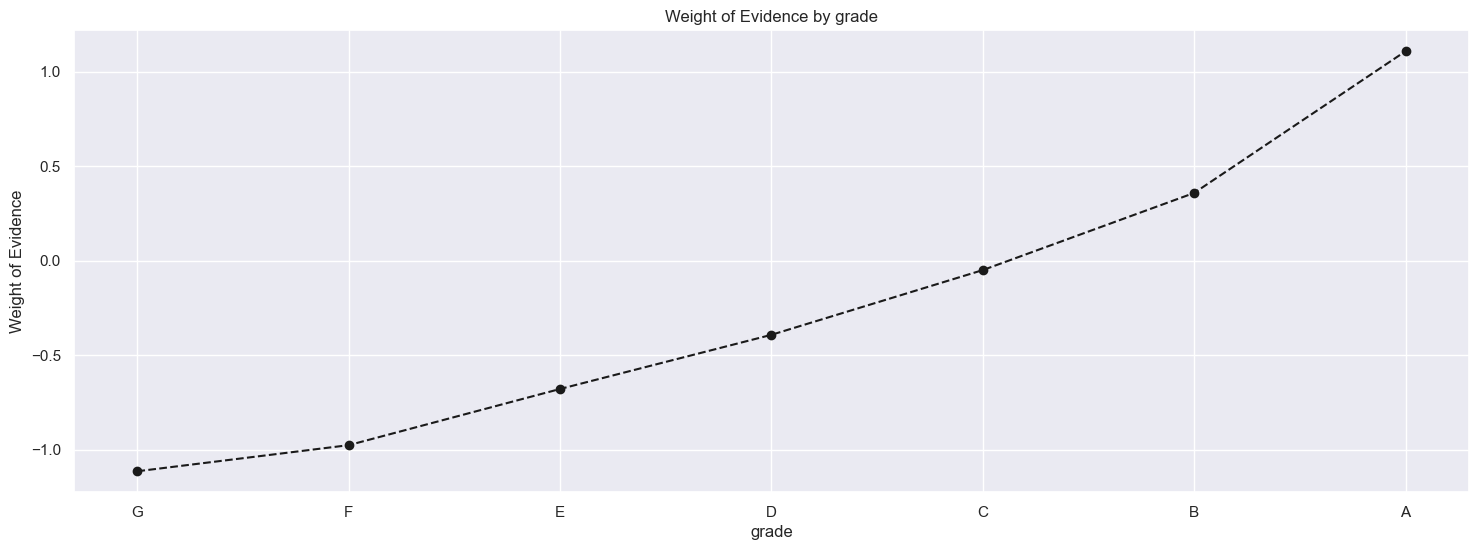

In [88]:
plot_by_woe(df_grade_woe)

In [89]:
df_inputs_prepr.columns.values

array(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan',
       'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
       'last_credit_pull_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint

# Preprocessing Discrete Variables: Creating Dummy Variables in Excel, Part1

## ['home_ownership']

In [90]:
df_home_woe = woe_discrete(loan_data_inputs_train, 'home_ownership', loan_data_targets_train)
df_home_woe

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,137,0.795620,0.000367,109.0,28.0,0.000328,0.000687,-0.738602,NaN,NaN,inf
1,NONE,40,0.850000,0.000107,34.0,6.0,0.000102,0.000147,-0.363144,0.054380,0.375458,inf
2,RENT,150599,0.873870,0.403720,131604.0,18995.0,0.396099,0.465815,-0.162123,0.023870,0.201021,inf
3,OWN,33295,0.892536,0.089256,29717.0,3578.0,0.089442,0.087743,0.019170,0.018666,0.181294,inf
4,MORTGAGE,188956,0.903835,0.506546,170785.0,18171.0,0.514026,0.445608,0.142834,0.011298,0.123663,inf
5,ANY,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,0.096165,inf,inf


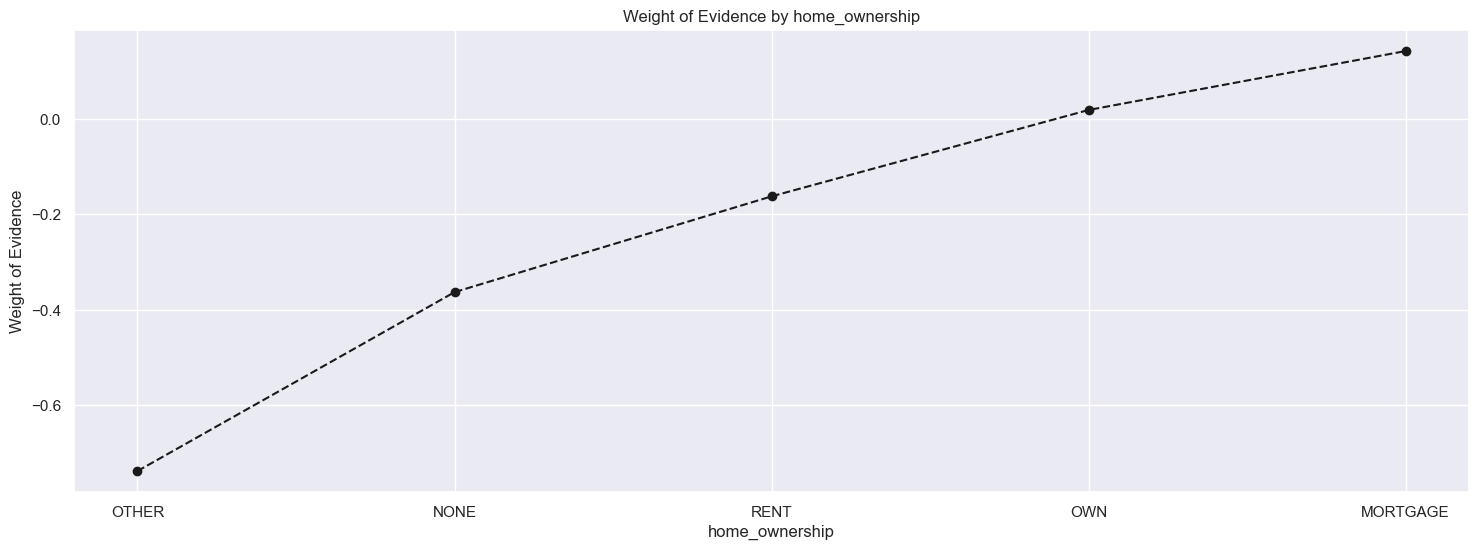

In [91]:
plot_by_woe(df_home_woe)

In [92]:

'''
df_inputs_prepr['home_ownership:rent_other_none_any'] = sum([
    df_inputs_prepr['home_ownership:RENT'],
    df_inputs_prepr['home_ownership:OTHER'],
    df_inputs_prepr['home_ownership:NONE'],
    df_inputs_prepr['home_ownership:ANY']
])

df_inputs_prepr = df_inputs_prepr.drop('home_ownership:rent_other_none_any', axis = 1)

'''

"\ndf_inputs_prepr['home_ownership:rent_other_none_any'] = sum([\n    df_inputs_prepr['home_ownership:RENT'],\n    df_inputs_prepr['home_ownership:OTHER'],\n    df_inputs_prepr['home_ownership:NONE'],\n    df_inputs_prepr['home_ownership:ANY']\n])\n\ndf_inputs_prepr = df_inputs_prepr.drop('home_ownership:rent_other_none_any', axis = 1)\n\n"

In [93]:
df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([
    df_inputs_prepr['home_ownership:RENT'],
    df_inputs_prepr['home_ownership:OTHER'],
    df_inputs_prepr['home_ownership:NONE'],
    df_inputs_prepr['home_ownership:ANY']
])

In [94]:
df_inputs_prepr.columns.values

array(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan',
       'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
       'last_credit_pull_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint

# Preprocessing Discrete Variables: Creating Dummy Variables in Excel, Part2

## ['state']

In [95]:
df_inputs_prepr['addr_state'].unique()

array(['SC', 'NJ', 'GA', 'MA', 'CA', 'IL', 'NC', 'NY', 'TX', 'CT', 'FL',
       'VA', 'UT', 'AZ', 'MD', 'WI', 'MI', 'CO', 'TN', 'IN', 'AL', 'NV',
       'MT', 'RI', 'OR', 'MN', 'KS', 'AK', 'PA', 'OH', 'WA', 'KY', 'OK',
       'MO', 'NM', 'HI', 'WV', 'LA', 'VT', 'AR', 'DC', 'SD', 'NH', 'WY',
       'MS', 'DE', 'IA', 'NE', 'ID', 'ME'], dtype=object)

In [96]:
df_state_woe = woe_discrete(df_inputs_prepr, 'addr_state', df_targets_prepr)
df_state_woe

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,NE,13,0.461538,0.000035,6.0,7.0,0.000018,0.000172,-2.251896,NaN,NaN,inf
1,IA,13,0.769231,0.000035,10.0,3.0,0.000030,0.000074,-0.893772,0.307692,1.358123,inf
2,NV,5221,0.864585,0.013996,4514.0,707.0,0.013586,0.017338,-0.243837,0.095355,0.649935,inf
3,FL,25211,0.875808,0.067585,22080.0,3131.0,0.066456,0.076782,-0.144425,0.011223,0.099411,inf
4,HI,2001,0.877061,0.005364,1755.0,246.0,0.005282,0.006033,-0.132852,0.001253,0.011573,inf
5,AL,4671,0.877328,0.012522,4098.0,573.0,0.012334,0.014052,-0.130376,0.000267,0.002476,inf
6,NM,2075,0.883373,0.005563,1833.0,242.0,0.005517,0.005935,-0.072973,0.006045,0.057403,inf
7,VA,11366,0.883864,0.030470,10046.0,1320.0,0.030236,0.032370,-0.068202,0.000491,0.004771,inf
8,NY,32211,0.883984,0.086350,28474.0,3737.0,0.085701,0.091643,-0.067037,0.000120,0.001165,inf
9,OK,3284,0.884287,0.008804,2904.0,380.0,0.008740,0.009319,-0.064072,0.000304,0.002965,inf


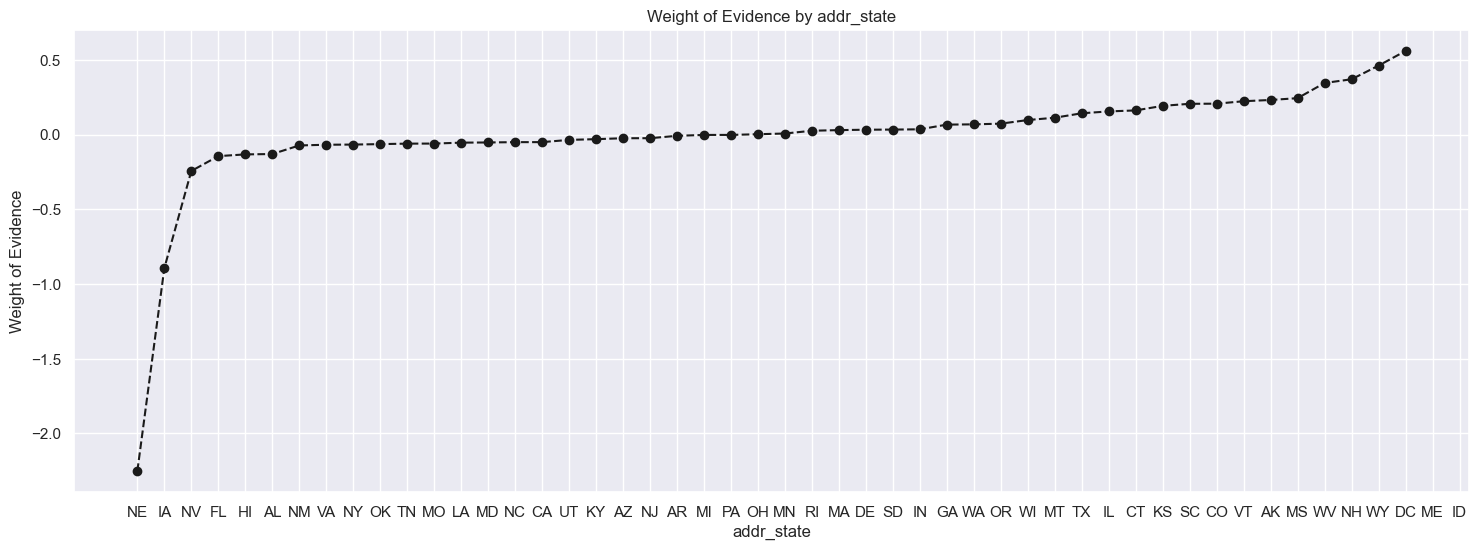

In [97]:
plot_by_woe(df_state_woe)

In [98]:
if 'addr_state:ND' in df_inputs_prepr.columns.values:
    pass
else:
    df_inputs_prepr['addr_state:ND'] = 0

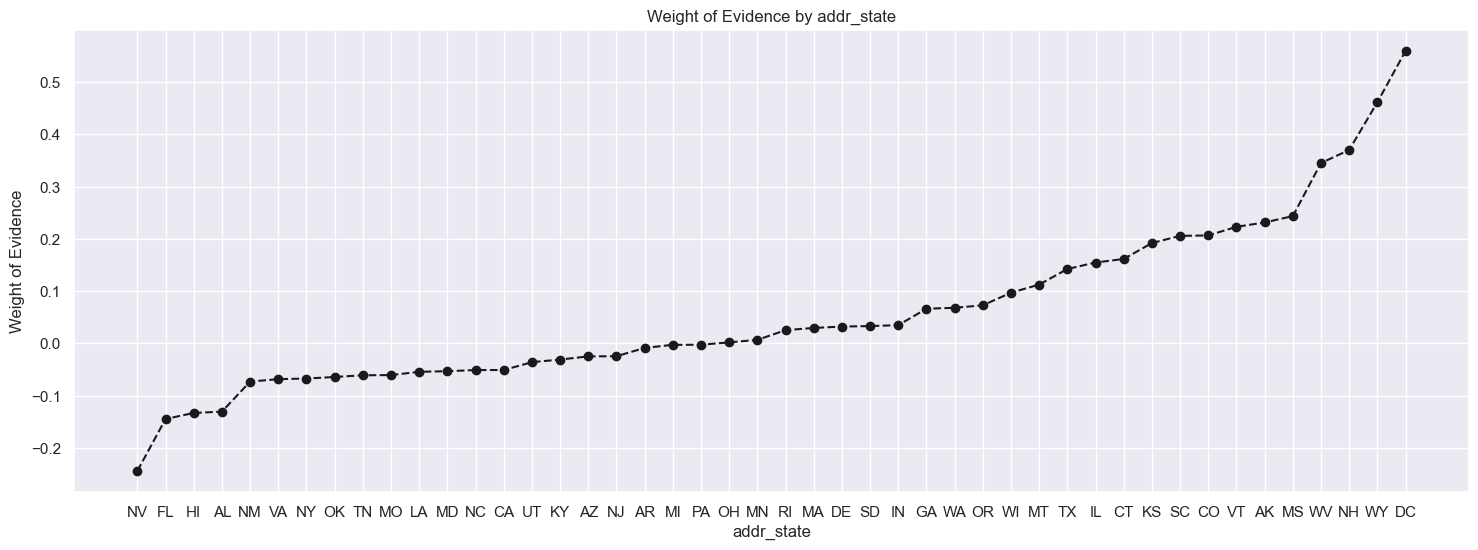

In [99]:
plot_by_woe(df_state_woe.iloc[2: -2, :])

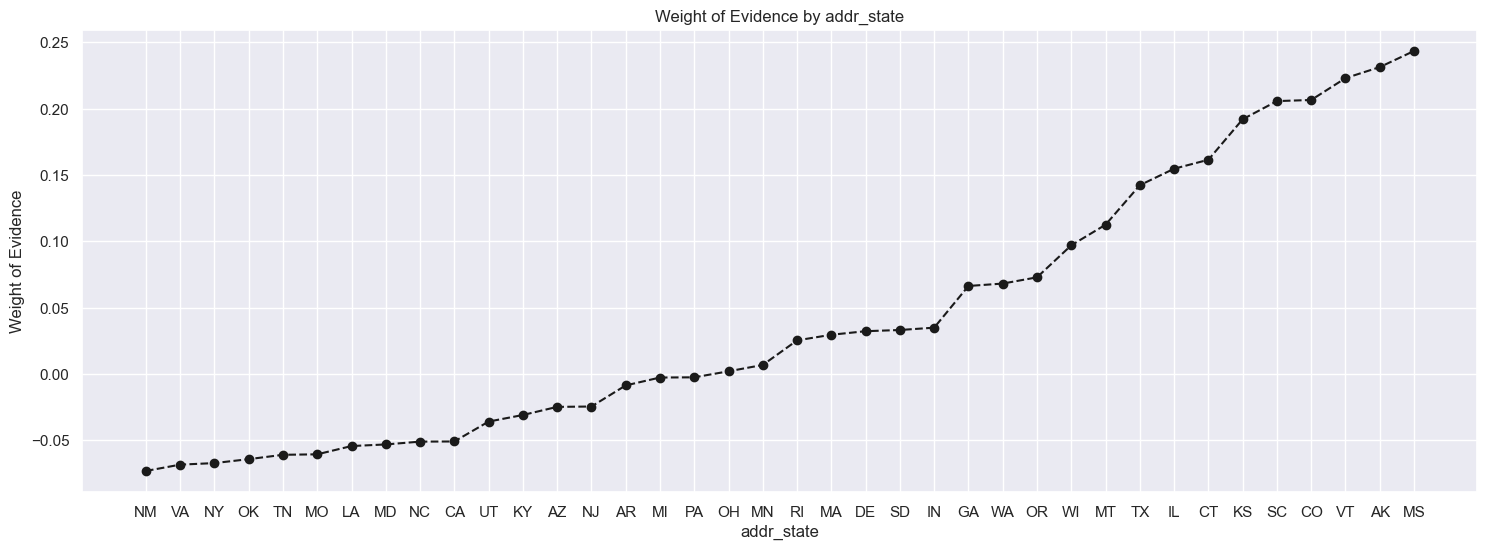

In [100]:
plot_by_woe(df_state_woe.iloc[6: -6, :])

# then back to the table, NY & CA got higher n_obs/prop_n_obs  

In [101]:
# We create the following categories:
# 'ND' 'NE' 'IA' NV' 'FL' 'HI' 'AL'
# 'NM' 'VA'
# 'NY'
# 'OK' 'TN' 'MO' 'LA' 'MD' 'NC'
# 'CA'
# 'UT' 'KY' 'AZ' 'NJ'
# 'AR' 'MI' 'PA' 'OH' 'MN'
# 'RI' 'MA' 'DE' 'SD' 'IN'
# 'GA' 'WA' 'OR'
# 'WI' 'MT'
# 'TX'
# 'IL' 'CT'
# 'KS' 'SC' 'CO' 'VT' 'AK' 'MS'
# 'WV' 'NH' 'WY' 'DC' 'ME' 'ID'

# 'IA_NV_HI_ID_AL_FL' will be the reference category.

df_inputs_prepr['addr_state:ND_NE_IA_NV_FL_HI_AL'] = sum([
    df_inputs_prepr['addr_state:ND'],
    df_inputs_prepr['addr_state:NE'],
    df_inputs_prepr['addr_state:IA'],
    df_inputs_prepr['addr_state:NV'],
    df_inputs_prepr['addr_state:FL'],
    df_inputs_prepr['addr_state:HI'],
    df_inputs_prepr['addr_state:AL']
])

df_inputs_prepr['addr_state:NM_VA'] = sum([
    df_inputs_prepr['addr_state:NM'],
    df_inputs_prepr['addr_state:VA']
])

df_inputs_prepr['addr_state:OK_TN_MO_LA_MD_NC'] = sum([
    df_inputs_prepr['addr_state:OK'],
    df_inputs_prepr['addr_state:TN'],
    df_inputs_prepr['addr_state:MO'],
    df_inputs_prepr['addr_state:LA'],
    df_inputs_prepr['addr_state:MD'],
    df_inputs_prepr['addr_state:NC']
])

df_inputs_prepr['addr_state:UT_KY_AZ_NJ'] = sum([
    df_inputs_prepr['addr_state:UT'],
    df_inputs_prepr['addr_state:KY'],
    df_inputs_prepr['addr_state:AZ'],
    df_inputs_prepr['addr_state:NJ']
])

df_inputs_prepr['addr_state:AR_MI_PA_OH_MN'] = sum([
    df_inputs_prepr['addr_state:AR'],
    df_inputs_prepr['addr_state:MI'],
    df_inputs_prepr['addr_state:PA'],
    df_inputs_prepr['addr_state:OH'],
    df_inputs_prepr['addr_state:MN']
])

df_inputs_prepr['addr_state:RI_MA_DE_SD_IN'] = sum([
    df_inputs_prepr['addr_state:RI'],
    df_inputs_prepr['addr_state:MA'],
    df_inputs_prepr['addr_state:DE'],
    df_inputs_prepr['addr_state:SD'],
    df_inputs_prepr['addr_state:IN']
])

df_inputs_prepr['addr_state:GA_WA_OR'] = sum([
    df_inputs_prepr['addr_state:GA'],
    df_inputs_prepr['addr_state:WA'],
    df_inputs_prepr['addr_state:OR']
])

df_inputs_prepr['addr_state:WI_MT'] = sum([
    df_inputs_prepr['addr_state:WI'],
    df_inputs_prepr['addr_state:MT']
])

df_inputs_prepr['addr_state:IL_CT'] = sum([
    df_inputs_prepr['addr_state:IL'],
    df_inputs_prepr['addr_state:CT']
])

df_inputs_prepr['addr_state:KS_SC_CO_VT_AK_MS'] = sum([
    df_inputs_prepr['addr_state:KS'],
    df_inputs_prepr['addr_state:SC'],
    df_inputs_prepr['addr_state:CO'],
    df_inputs_prepr['addr_state:VT'],
    df_inputs_prepr['addr_state:AK'],
    df_inputs_prepr['addr_state:MS']
])

df_inputs_prepr['addr_state:WV_NH_WY_DC_ME_ID'] = sum([
    df_inputs_prepr['addr_state:WV'],
    df_inputs_prepr['addr_state:NH'],
    df_inputs_prepr['addr_state:WY'],
    df_inputs_prepr['addr_state:DC'],
    df_inputs_prepr['addr_state:ME'],
    df_inputs_prepr['addr_state:ID']
])


# ['verification_status']

In [102]:
df_inputs_prepr['verification_status'].unique()

array(['Source Verified', 'Not Verified', 'Verified'], dtype=object)

In [103]:
df_verification_woe = woe_discrete(df_inputs_prepr, 'verification_status', df_targets_prepr)
df_verification_woe

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,134414,0.872781,0.360332,117314.0,17100.0,0.353090,0.419344,-0.171969,NaN,NaN,0.020384
1,Source Verified,120030,0.895918,0.321772,107537.0,12493.0,0.323663,0.306366,0.054922,0.023137,0.226891,0.020384
2,Not Verified,118584,0.905679,0.317896,107399.0,11185.0,0.323248,0.274290,0.164232,0.009761,0.109311,0.020384


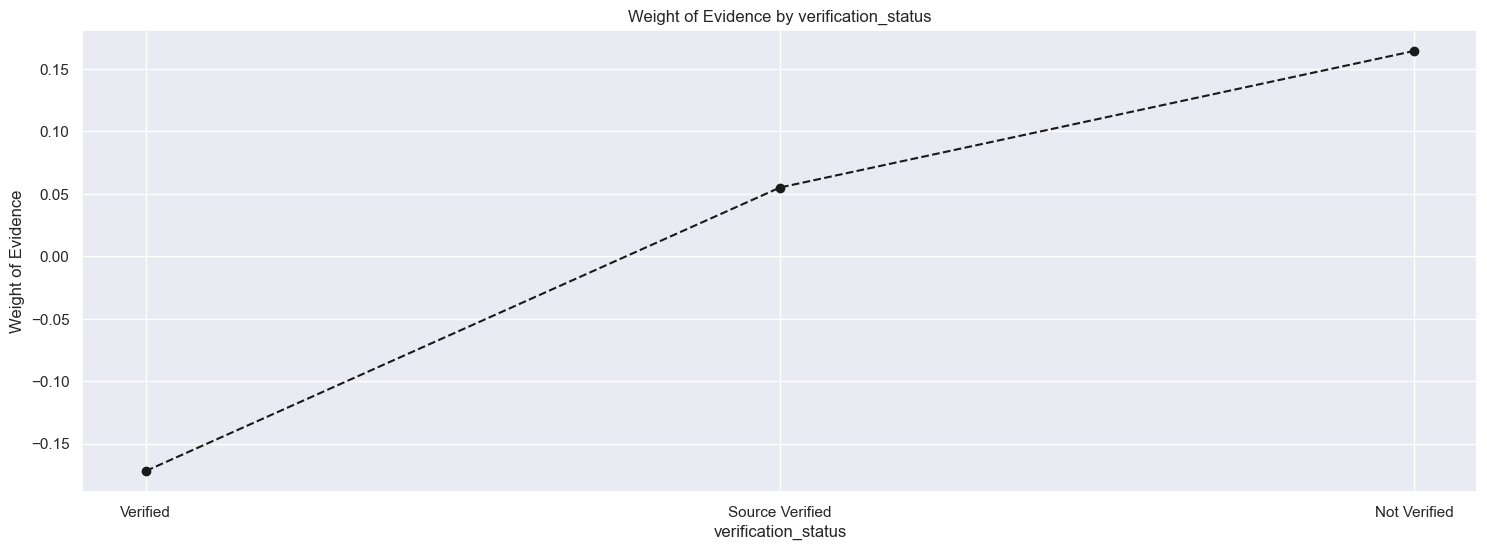

In [104]:
plot_by_woe(df_verification_woe)

🕵️‍♂️ 1. 反直觉的 WoE 趋势 (The Counterintuitive Trend)
你看 WoE 这一列的数据走势：

Verified (已验证收入)：WoE = -0.17 （表现最差，风险最高）

Source Verified (来源已验证)：WoE = 0.05 （表现中等）

Not Verified (未验证收入)：WoE = 0.16 （表现最好，风险最低）


👥 2. 查验样本量 (Check n_obs)
按照我们的标准工作流，看到反常理的现象，第一步必须看样本量，排除统计噪音：

Verified: 134,414 人

Source Verified: 120,030 人

Not Verified: 118,584 人

结论： 每一个类别的 n_obs 都极其庞大（都在 11 万人以上），且分布非常均匀。这说明这不是数据噪音（Statistical Noise），而是确凿无疑的真实业务规律！我们完全不需要做任何类别合并（Coarse Classing）。

📏 3. 评判变量的预测力 (Check Information Value - IV)
看表格最右侧的 IV 列，总分是 0.020384。

回忆一下我们的 IV 黄金法则：0.02 到 0.1 之间属于 Weak Predictive Power（弱预测力）。

这个变量刚好踩在 0.02 的及格线上。它虽然能提供一点点信息，但在最终的模型里，它绝对不会是挑大梁的主力特征，只能算是个“打辅助”的变量。

🛠️ 最终的特征工程决策 (The Action Plan)
基于以上三点，我们在代码里的动作应该非常干净利落：

保留全类别： 因为没有 Sparse Categories（稀疏类别），且 WoE 是完美单调递增的，所以 3 个类别全数保留。

Reference Category（黑名单）： 把风险最高（WoE 最低）的 Verified 选为基准，踢出模型。

Dummy Variables（白名单）： 剩下的 Source Verified 和 Not Verified 作为正式特征，放进最终的特征清单表里。

# ['purpose']

In [105]:
df_inputs_prepr['purpose'].unique()

array(['debt_consolidation', 'educational', 'other', 'home_improvement',
       'credit_card', 'major_purchase', 'wedding', 'small_business',
       'vacation', 'house', 'car', 'moving', 'renewable_energy',
       'medical'], dtype=object)

In [106]:
df_purpose_woe = woe_discrete(df_inputs_prepr, 'purpose', df_targets_prepr)
df_purpose_woe

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,5582,0.786098,0.014964,4388.0,1194.0,0.013207,0.029280,-0.796180,NaN,NaN,0.035418
1,educational,333,0.801802,0.000893,267.0,66.0,0.000804,0.001619,-0.700151,0.015704,0.096029,0.035418
2,moving,2392,0.839465,0.006412,2008.0,384.0,0.006044,0.009417,-0.443493,0.037663,0.256658,0.035418
3,house,1830,0.860109,0.004906,1574.0,256.0,0.004737,0.006278,-0.281547,0.020644,0.161946,0.035418
4,other,18884,0.862264,0.050624,16283.0,2601.0,0.049008,0.063784,-0.263519,0.002155,0.018028,0.035418
5,renewable_energy,281,0.864769,0.000753,243.0,38.0,0.000731,0.000932,-0.242270,0.002504,0.021250,0.035418
6,medical,3684,0.868350,0.009876,3199.0,485.0,0.009628,0.011894,-0.211300,0.003581,0.030969,0.035418
7,wedding,1887,0.881823,0.005059,1664.0,223.0,0.005008,0.005469,-0.087937,0.013473,0.123363,0.035418
8,vacation,1991,0.882471,0.005337,1757.0,234.0,0.005288,0.005738,-0.081703,0.000648,0.006234,0.035418
9,debt_consolidation,219183,0.886884,0.587578,194390.0,24793.0,0.585071,0.607999,-0.038440,0.004413,0.043263,0.035418


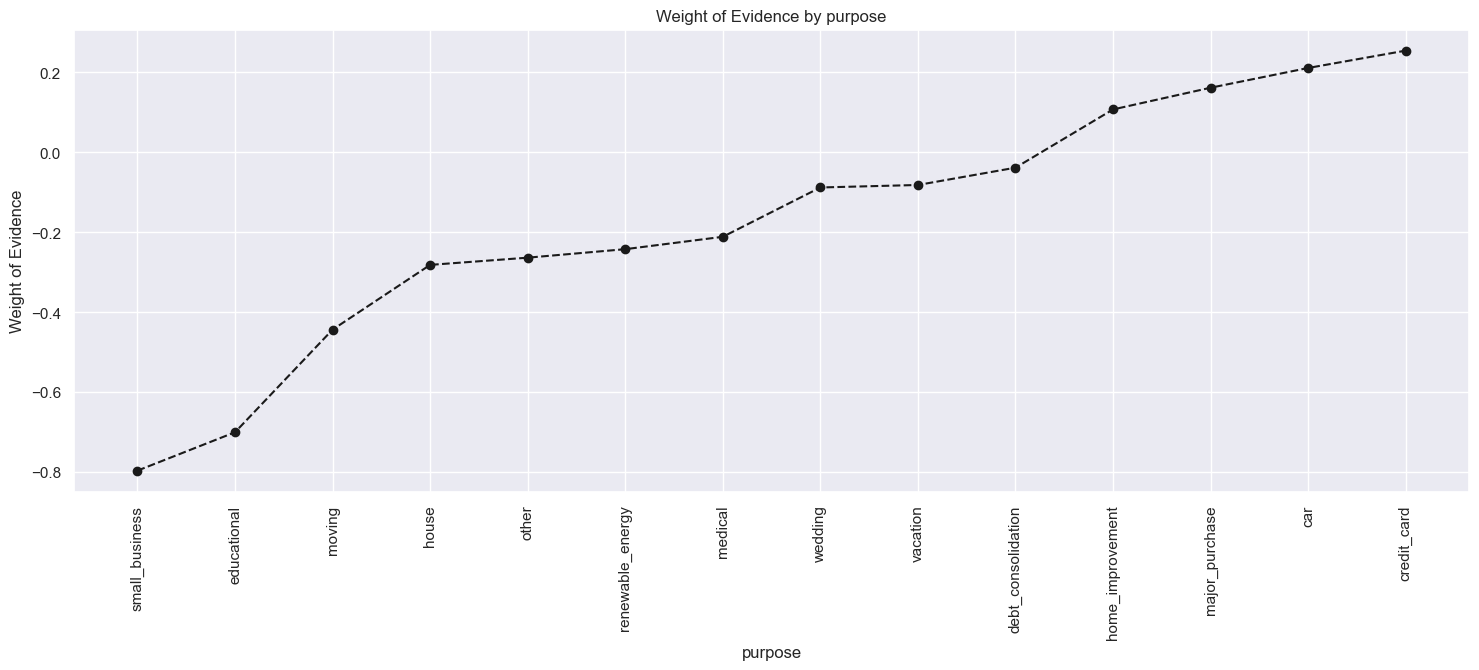

In [107]:
plot_by_woe(df_purpose_woe, 90)

In [108]:
# We combine 'educational', 'small_business', 'wedding', 'renewable_energy', 'moving', 'house' in one category: 'educ__sm_b__wedd__ren_en__mov__house'.
# We combine 'other', 'medical', 'vacation' in one category: 'oth__med__vacation'.
# We combine 'major_purchase', 'car', 'home_improvement' in one category: 'major_purch__car__home_impr'.
# We leave 'debt_consolidtion' in a separate category.
# We leave 'credit_card' in a separate category.
# 'educ__sm_b__wedd__ren_en__mov__house' will be the reference category.

df_inputs_prepr['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([
    df_inputs_prepr['purpose:educational'], 
    df_inputs_prepr['purpose:small_business'],
    df_inputs_prepr['purpose:wedding'], 
    df_inputs_prepr['purpose:renewable_energy'],
    df_inputs_prepr['purpose:moving'], 
    df_inputs_prepr['purpose:house']
    ])

df_inputs_prepr['purpose:oth__med__vacation'] = sum([
    df_inputs_prepr['purpose:other'], 
    df_inputs_prepr['purpose:medical'],
    df_inputs_prepr['purpose:vacation']
    ])

df_inputs_prepr['purpose:major_purch__car__home_impr'] = sum([
    df_inputs_prepr['purpose:major_purchase'], 
    df_inputs_prepr['purpose:car'],
    df_inputs_prepr['purpose:home_improvement']
    ])

In [109]:
df_inputs_prepr.columns.values

array(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan',
       'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
       'last_credit_pull_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint

# ['initial_list_status']

In [110]:
df_inputs_prepr['initial_list_status'].unique()

array(['f', 'w'], dtype=object)

In [111]:
df_initial_list_status_woe = woe_discrete(df_inputs_prepr, 'initial_list_status', df_targets_prepr)
df_initial_list_status_woe

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,242514,0.879694,0.650123,213338.0,29176.0,0.642101,0.715484,-0.108214,NaN,NaN,0.02478
1,w,130514,0.911105,0.349877,118912.0,11602.0,0.357899,0.284516,0.229461,0.031412,0.337675,0.02478


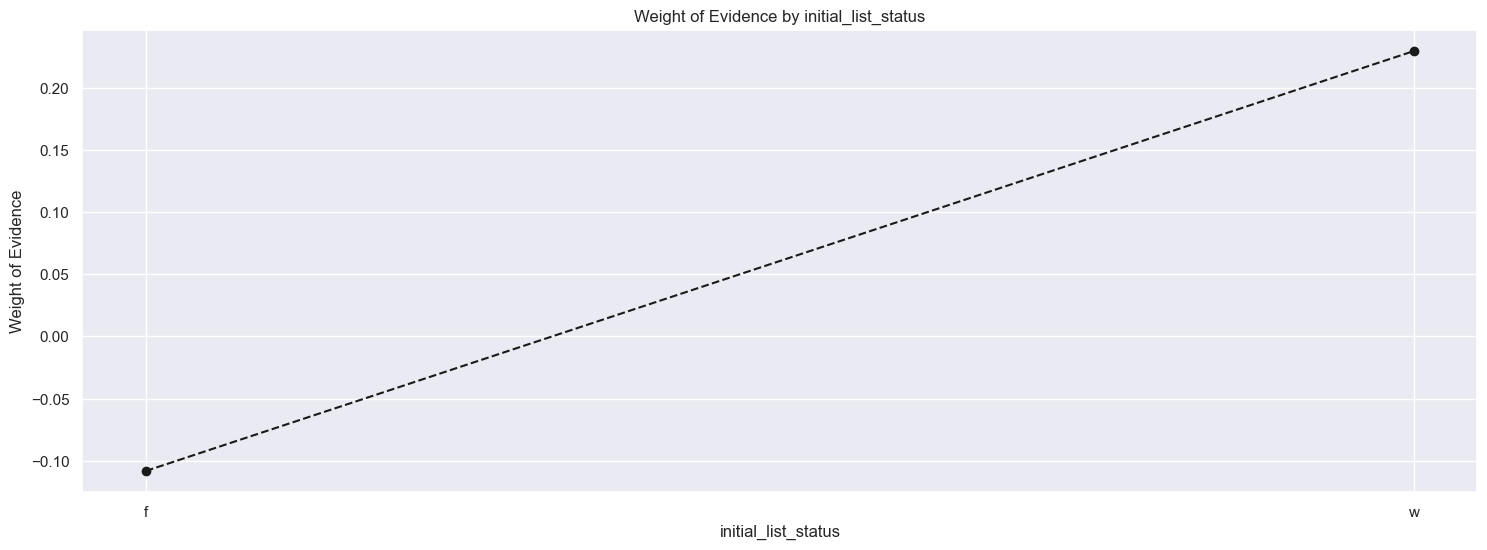

In [112]:
plot_by_woe(df_initial_list_status_woe)